# Example TokaMaker Equilibrium for ARC V2D

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import CubicSpline
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
sys.path.append('/mnt/homes/sg3909/OpenFUSIONToolkit/install_release/python/')
# tokamaker_python_path = os.getenv('OFT_ROOTPATH')
# if tokamaker_python_path is not None:
#     sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

## Load reference eqdsk

In [3]:
eq = read_eqdsk('geqdsk-ARCv3aendflattop-20250308.txt')

## Setup solver

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [4]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   sophia
Revision id:          e984ec0
Parallelization Info:
  # of MPI tasks      =    1
  # of NUMA nodes     =    1
  # of OpenMP threads =    2
Fortran input file    = /tmp/oft_2347006/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker

In [5]:
meshname = 'arc_mesh_cubit.h5'

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh(f'{meshname}')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)

mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.maxits = 200
#mygs.settings.lim_zmax = 1.75
mygs.setup(order=3, F0=eq['rcentr']*eq['bcentr'])


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.060E+02
    # of points  =   18172
    # of edges   =   54431
    # of cells   =   36260
    # of boundary points =      82
    # of boundary edges  =      82
    # of boundary cells  =      78
  Resolution statistics:
    hmin =  1.000E-02
    hrms =  8.532E-02
    hmax =  7.708E-01
  Surface grounded at vertex    2381

           2

**** Creating Lagrange FE space
  Order  =    3
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.1944909999999998E-003


In [7]:
mygs.r

array([[ 3.415     ,  0.72873954,  0.        ],
       [ 3.49476814,  0.75894418,  0.        ],
       [ 3.415     ,  0.79041193,  0.        ],
       ...,
       [ 6.89187526, -1.53152912,  0.        ],
       [ 6.90699299, -1.55762738,  0.        ],
       [ 6.87934582, -1.5487413 ,  0.        ]])

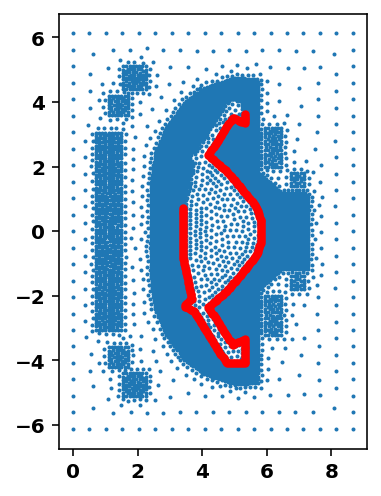

In [6]:
ind_final = 280

lim_inds = np.array([1, 634, 6, 7, 610, 12, 10, 629, 18, 17, 525, 526, 21, 19, 38, 36, 24, 22, 27, 25, 30, 28, 608, 35, 534, 535, 532, 524, 225, 41, 39, 42, 84, 82, 83, 80, 78, 75, 76, 73, 46, 44, 48, 51, 49, 71, 72, 54, 52, 57, 55, 58, 59, 61, 64, 62, 636, 543, 509, 69, 67, 193, 186, 179, 150, 144, 142, 135, 129, 119, 120, 117, 114, 115, 162, 167, 112, 93, 87, 85, 88, 133, 96, 94, 99, 98, 600, 103, 101, 106, 104, 641, 640, 601, 597, 137, 134, 131, 123, 121, 127, 125, 126, 648, 140, 138, 163, 160, 147, 145, 148, 153, 151, 154, 156, 155, 159, 158, 165, 164, 168, 175, 173, 177, 91, 89, 182, 181, 183, 637, 191, 653, 643, 196, 194, 645, 646, 647, 649, 206, 205, 651, 652, 541, 542, 212, 210, 512, 215, 213, 655, 218, 219, 221, 530, 531, 227, 228, 545, 231, 229, 234, 236, 235, 239, 237, 539, 242, 240, 245, 244, 618, 250, 248, 253, 251, 528, 263, 259, 256, 254, 257, 262, 260, 584, 585, 269, 266, 264, 590, 271, 580, 560, 274, 272, 275, 281, 278, 276, 583, 564, 558, 284, 282, 290, 287, 285, 565, 562, 551, 552, 293, 291, 298, 296, 301, 299, 304, 305, 308, 306, 503, 499, 496, 497, 494, 489, 486, 480, 478, 311, 312, 473, 468, 465, 463, 458, 456, 451, 446, 447, 436, 435, 315, 313, 384, 318, 316, 319, 322, 320, 376, 326, 324, 329, 328, 332, 330, 335, 334, 373, 338, 339, 341, 343, 368, 369, 355, 346, 344, 348, 350, 349, 351, 353, 354, 672, 358, 356, 359, 516, 515, 374, 371, 362, 360, 366, 364, 365, 372, 378, 380, 379, 382, 391, 390, 388, 385, 386, 395, 393, 397, 399, 401, 402, 404, 670, 407, 669, 409, 668, 412, 414, 413, 665, 417, 415, 419, 662, 422, 424, 423, 427, 426, 684, 431, 429, 433, 452, 453, 439, 437, 440, 442, 444, 445, 449, 454, 460, 461, 464, 471, 469, 476, 475, 481, 482, 483, 488, 490, 491, 549, 550, 570, 521, 522, 502, 500, 504, 505, 657, 518, 223, 3])
lim_inds = lim_inds-1
plt.scatter(mesh_pts[:,0], mesh_pts[:,1], s = 1)
plt.scatter(mesh_pts[lim_inds[:ind_final],0], mesh_pts[lim_inds[:ind_final],1], s = 10, c='red')
plt.gca().set_aspect('equal')
# plt.xlim([3,7])
# plt.ylim([-3,3])

In [7]:
cond_dict

{'CHANNEL': {'reg_id': 3,
  'cond_id': 0,
  'eta': 0.005,
  'noncontinuous': False,
  'allow_xpoints': True},
 'VESSEL_INNER': {'reg_id': 4,
  'cond_id': 1,
  'eta': 6e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'VESSEL_OUTER': {'reg_id': 5,
  'cond_id': 2,
  'eta': 6e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'BLANKET': {'reg_id': 6,
  'cond_id': 3,
  'eta': 7.4e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'FLIBE': {'reg_id': 7,
  'cond_id': 4,
  'eta': 0.005,
  'noncontinuous': False,
  'allow_xpoints': True}}

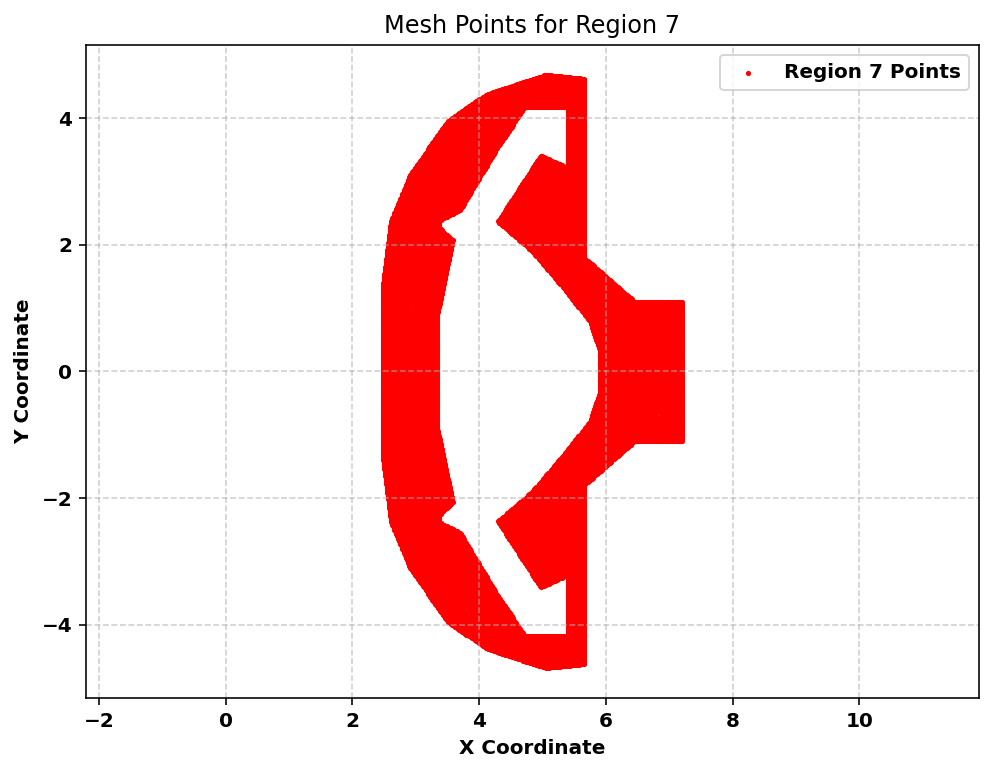

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assuming you already have mesh_pts, mesh_lc, and mesh_reg loaded ---
# For this example, let's say you want to plot Region "1"
target_region_id = 7

# 1. Create a boolean mask to find elements in the target region
region_mask = (mesh_reg == target_region_id)

# 2. Extract only the connectivity (elements) for that region
elements_in_region = mesh_lc[region_mask]

# 3. Find the unique point indices used by these specific elements
# np.unique flattens the array and removes duplicate nodes shared by adjacent elements
point_indices = np.unique(elements_in_region)

# 4. Extract the actual X, Y (and Z) coordinates from mesh_pts
points_in_region = mesh_pts[point_indices]

# 5. Plot the points (Assuming 2D for this example)
plt.figure(figsize=(8, 6))

# points_in_region[:, 0] is X, points_in_region[:, 1] is Y
plt.scatter(points_in_region[:, 0], points_in_region[:, 1], 
            c='red', marker='.', s=10, label=f'Region {target_region_id} Points')

plt.title(f'Mesh Points for Region {target_region_id}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal') # Ensures the aspect ratio isn't stretched
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [9]:
coil_dict

{'CS1U': {'reg_id': 8,
  'coil_id': 0,
  'nturns': 100,
  'coil_set': 'CS1U',
  'allow_xpoints': False},
 'CS1L': {'reg_id': 9,
  'coil_id': 1,
  'nturns': 100,
  'coil_set': 'CS1L',
  'allow_xpoints': False},
 'CS2U': {'reg_id': 10,
  'coil_id': 2,
  'nturns': 100,
  'coil_set': 'CS2U',
  'allow_xpoints': False},
 'CS2L': {'reg_id': 11,
  'coil_id': 3,
  'nturns': 100,
  'coil_set': 'CS2L',
  'allow_xpoints': False},
 'CS3U': {'reg_id': 12,
  'coil_id': 4,
  'nturns': 100,
  'coil_set': 'CS3U',
  'allow_xpoints': False},
 'CS3L': {'reg_id': 13,
  'coil_id': 5,
  'nturns': 100,
  'coil_set': 'CS3L',
  'allow_xpoints': False},
 'PF1U': {'reg_id': 14,
  'coil_id': 6,
  'nturns': 100,
  'coil_set': 'PF1U',
  'allow_xpoints': False},
 'PF1L': {'reg_id': 15,
  'coil_id': 7,
  'nturns': 100,
  'coil_set': 'PF1L',
  'allow_xpoints': False},
 'PF2U': {'reg_id': 16,
  'coil_id': 8,
  'nturns': 100,
  'coil_set': 'PF2U',
  'allow_xpoints': False},
 'PF2L': {'reg_id': 17,
  'coil_id': 9,
  'nturn

In [10]:
mygs.nregs

23

### Define a vertical stability coil

In [11]:
### Define a vertical stability coil

vsc = 'PF5'
mygs.set_coil_vsc({f'{vsc}U': 1.0, f'{vsc}L': -1.0})

### Define hard limits on coil currents
Hard limits on coil currents can be set using `set_coil_bounds`, which are then used in the shape fitting below.

Note that the size of the bounds array is (ncoils+1,2) as bounds can also be set for the VSC set, which is treated as a separate degree of freedom (virtual coil) if defined.

In [6]:
### Define hard limits on coil currents

coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

## Set global targets

In [7]:
pax_target = eq['pres'][0]
Ip_target = abs(eq['ip'])
mygs.set_targets(Ip=Ip_target,pax=pax_target)
#mygs.set_targets(Ip=Ip_target,Ip_ratio=0.48)

### Define shape targets
In order to constrain the shape of the plasma we can utilize two types of constraints:
 1. `isoflux` points, which are points we want to lie on the same flux surface (eg. the LCFS)
 2. `saddle` points, where we want the poloidal magnetic field to vanish (eg. X-points). While one can also use this constraint to enforce a magnetic axis location, instead `set_targets` should be used with arguments `R0` and `V0`.

**Note:** These constraints can be considered "soft" constraints, where the calculation attempts to minimize error in satisfying these constraints subject to other constraints and regularization.

Here we define a handful of isoflux points that we want to lie on the LCFS of the target equilibrium. Additionally, we define two X-points and set them as saddle constraints as well as add them to the list of isoflux points.

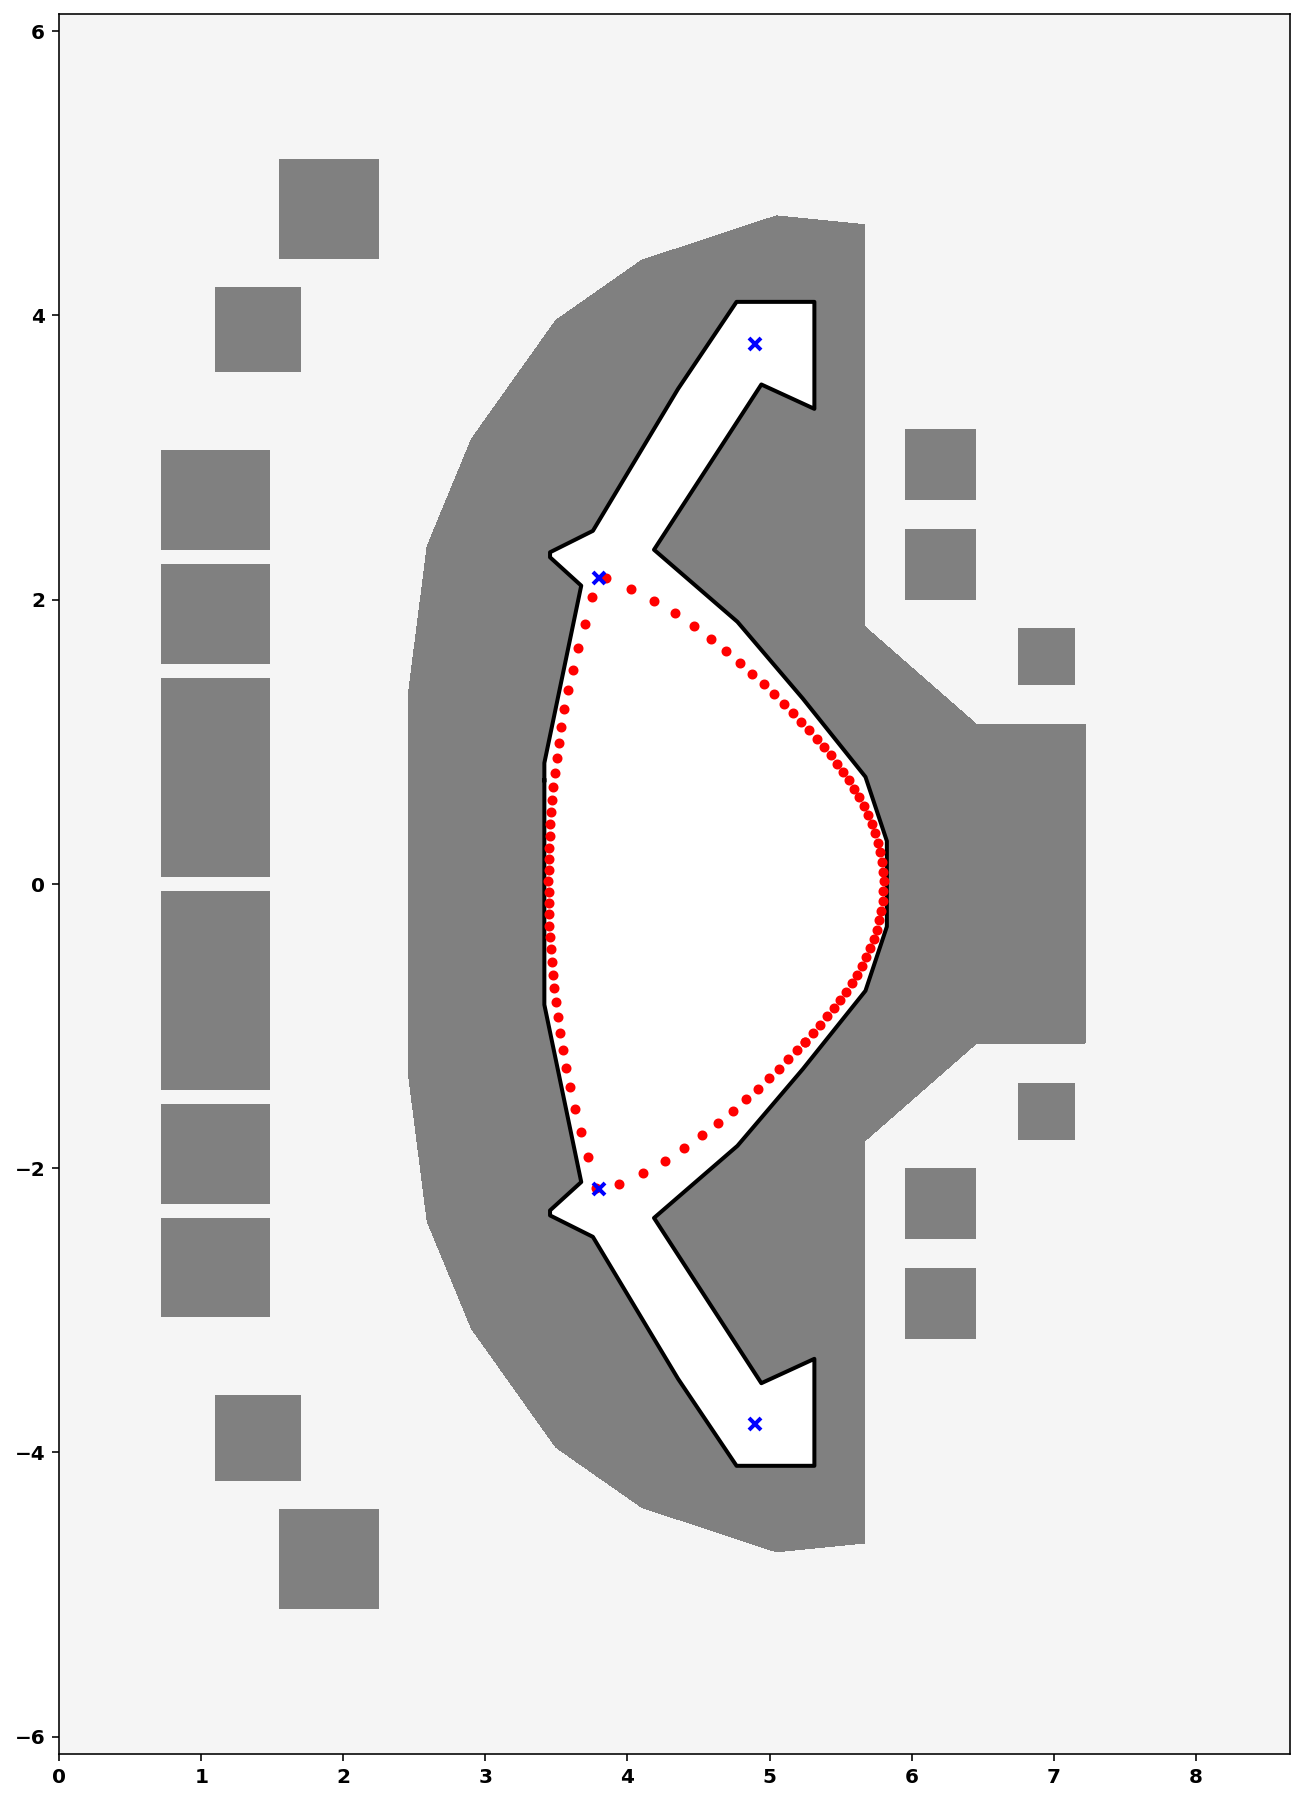

In [8]:
kappa = 1.75
delta = 0.6
squar = -0.05
a0 = 1.19
r0 = 4.57
z0 = 0

def update_boundary(r0, z0, a0, kappa, delta, squar, npts=20):
    thp = np.linspace(0,2*np.pi,npts+1)
    thp = thp[:-1]

    ra = r0 + a0*np.cos(thp + delta*np.sin(thp) - squar*np.sin(2*thp))
    za = z0 + kappa*a0*np.sin(thp + squar*np.sin(2*thp))
    return np.vstack([ra, za]).transpose()

boundary = update_boundary(r0, z0, a0, kappa, delta, squar)
boundary_weights = np.ones(len(boundary[:,0]))

x_points = np.array([[3.8, 2.15], [3.8, -2.15], [4.9, 3.8], [4.9, -3.8]])
x_weights = np.ones(len(x_points)) 

mygs.set_saddles(x_points, 2*x_weights)
# mygs.set_isoflux(boundary, 10*boundary_weights)

isoflux_pts = eq['rzout'].copy()#[::2]
mygs.set_isoflux(isoflux_pts, np.ones(len(isoflux_pts))*30)

fig, ax = plt.subplots(1,1, figsize=(20,16))
mygs.plot_machine(fig,ax)
plt.plot(isoflux_pts[:,0], isoflux_pts[:,1], 'r.')
plt.plot(x_points[:,0], x_points[:,1], 'bx')

### Define coil regularization matrix
In general, for a given coil set a given plasma shape cannot be exactly reproduced, which generally yields large amplitude coil currents if no constraint on the coil currents is applied. As a result, it is useful to include regularization terms for the coils to balance minimization of the shape error with the amplitude of current in the free coils. In TokaMaker these regularization terms have the general form of a vector of targets (often zero), a regularization matrix that maps the coil currents to the targets, and a vector of weights that can be used to control the relative impact of each term in the minimization.

Here we define three types of regularization targets:
 1. Targets that act to penalize up-down assymetry in U/L coil pairs
 2. A target to enforce the fixed relationship between CS1LI and CS1LO (also enforces this for the upper coil through other target types)
 3. Targets the act to penalize the amplitude of current in each coil

In the later case this regularization acts to penalize the amplitude of current in each coil, acting to balance coil current with error in the shape targets. Additionally, this target is also used to "disable" several coils by setting the weight on their targets high to strongly penalize non-zero current. Note that the VSC set is disabled to prevent up-down symmetric current in these coils. The actual up-down asymmetric current will be provided by the dedicated VSC virtual coil.

In [9]:
## Same regmat for all (might be ambitious)
def set_regularization(gs_obj, reg_targets, weight_mult=1):
    regularization_terms = []
    for name, coil in mygs.coil_sets.items():
        if name.find('L') >= 0: # We will set everything for upper coils
            continue
        if name == 'VSC':
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E4))
            continue
        # Targets for normal coils and their mirror
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=reg_targets.get(name,0.0),weight=1.E-1*weight_mult))
        regularization_terms.append(mygs.coil_reg_term({name: 1.0, name.replace('U','L'): -1.0},target=0.0,weight=1.E1))
    # Disable virtual VSC
    regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-1))
    # Pass regularization terms to TokaMaker
    gs_obj.set_coil_reg(reg_terms=regularization_terms)

/tmp/ipykernel_2347006/2692312231.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(coil_names, rotation = 90)


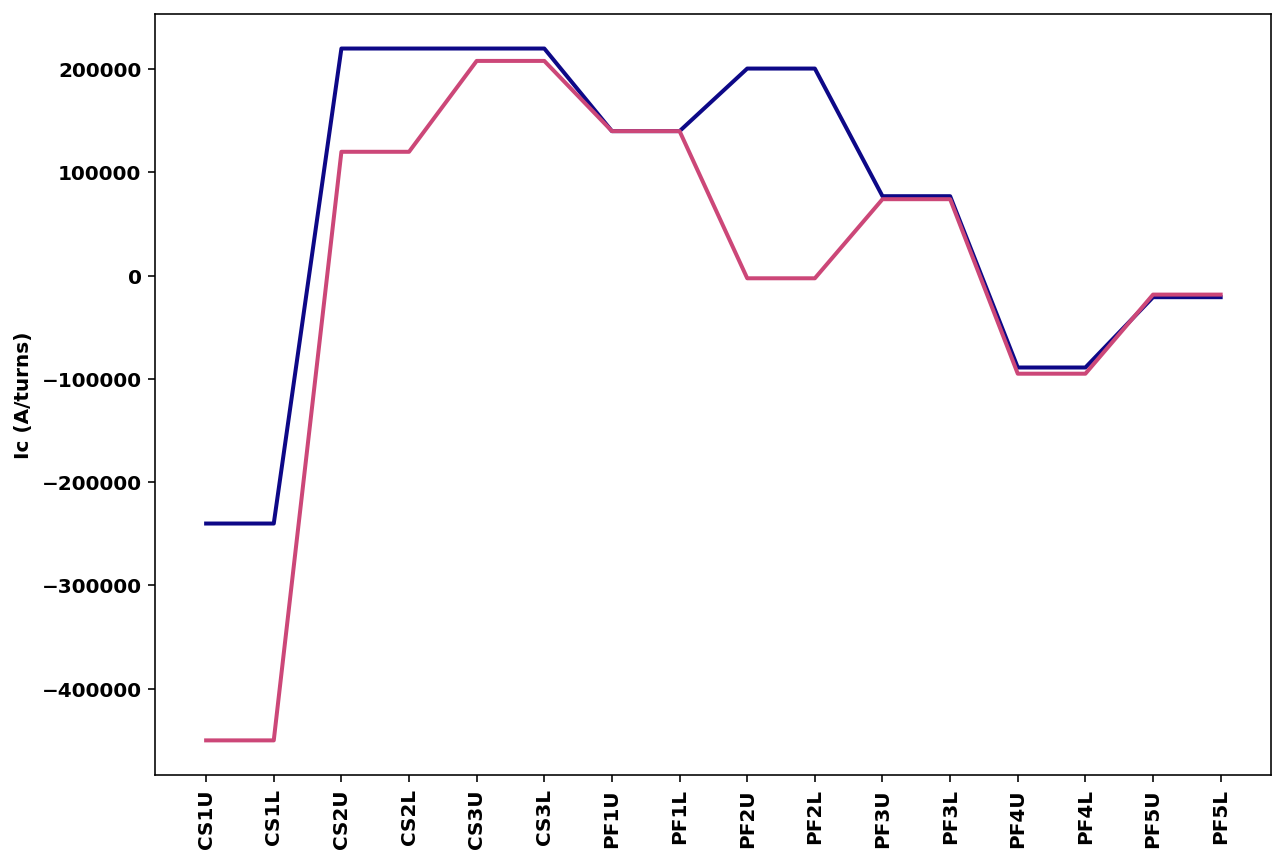

In [10]:
### Define coil targets

## Define times 
equil_nums = [1,2] # easy switch between start and end

# From freegs solution
ic_srt = np.array([24, 24, -22, -22, -22, -22, -14, -14, -20.06, -20.06, -7.7, -7.7, 8.89, 8.89, 2.08, 2.08]) * -1e6
ic_end = np.array([45, 45, -12, -12, -20.80, -20.80, -14, -14, 0.25, 0.25, -7.41, -7.41, 9.49, 9.49, 1.83, 1.83]) * -1e6

coil_names = mygs.coil_sets.keys()

# Sort into coil_targets
coil_targets = {}
coil_targets_all = {}
for i,equil_num in enumerate(equil_nums):
    target_currents = {}
    scale = np.linspace(0,1,len(equil_nums))[i]
    target_currents = ic_srt * (1-scale) + ic_end * scale      
    
    coil_targets[equil_num] = {} 
    coil_targets_all[equil_num] = {} 
    for name, coil in mygs.coil_sets.items():
        if name.find('U') >= 0: # Targets on upper coils only, since symmetry is enforced
            coil_targets[equil_num][name] = target_currents[coil['id']] / coil['net_turns']
        coil_targets_all[equil_num][name] = target_currents[coil['id']] / coil['net_turns'] # for plotting
        
# Plot to check
cmap = plt.get_cmap('plasma')
fig, ax = plt.subplots(1,1, figsize=(10,7))
for i,equil_num in enumerate(equil_nums):
    ax.plot(coil_names, np.array([coil_targets_all[equil_num][name] for name in coil_names]), c=cmap(i/len(equil_nums)))
ax.set_xticklabels(coil_names, rotation = 90)
ax.set_ylabel('Ic (A/turns)')
plt.show()

### Define flux functions
Although TokaMaker has a "default" profile for the F\*F' and P' terms this should almost never be used and one should instead choose an appropriate flux function for their application. In this case we use a simple cubic flux function with the same shape for both F\*F' and P'. Within TokaMaker this profile is represented as a piecewise linear function, which can be set up using the dictionary approach shown below.

*More tools to aide in setting these profiles are coming soon*. For example, Daniel already has a working H-mode pedestal profile with self-consistent bootstrap that we will merge in shortly.

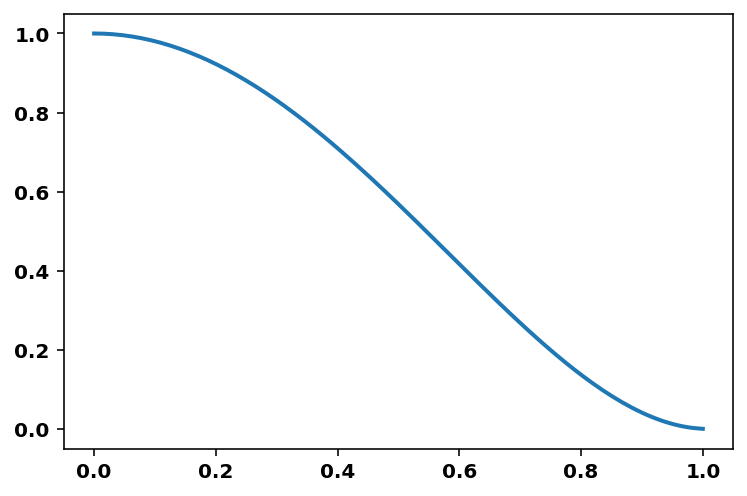

In [11]:
psi_eqdsk = np.linspace(0.0,1.0,eq['nr'])
# Create new F*F' profile
ffp_prof = {'type': 'linterp', 'x': psi_eqdsk, 'y': np.interp(psi_eqdsk,psi_eqdsk,eq['ffprim'])}
ffp_prof['y'] /= ffp_prof['y'][0] # Normalize profile (not required but convienient)
ffp_prof['y'][-1] = 0.0 # Set edge to zero
# Create new P' profile
pp_prof = {'type': 'linterp', 'x': psi_eqdsk, 'y': np.interp(psi_eqdsk,psi_eqdsk,eq['pprime'])}
pp_prof['y'] /= pp_prof['y'][0] # Normalize profile (not required but convienient)
pp_prof['y'][-1] = 0.0 # Set edge to zero
# Update profiles in TokaMaker
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

plt.plot(psi_eqdsk, ffp_prof['y'])

### Set resistivity profile from transport run

### Initialize equilibrium calculation
We can now compute a free-boundary equilibrium using these constraints. Note that before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using `init_psi`. This subroutine initializes the flux using the specified Ip_target from above, which is evenly distributed over the entire plasma region or only with a boundary defined using a center point (R,Z), minor radius (a), and elongation and triangularity. Coil currents are also initialized at this point using the constraints above and this uniform plasma current initialization. 

We plot the solution and coil currents after initialization but _before_ the Grad-Shafranov solve for reference.

In [12]:
equil_init = equil_nums[0]
set_regularization(mygs, coil_targets[equil_init])

 Saddle loc_before:    3.7777550358710172       -2.2860153364068179     
 cell_active:           35
 Cell:           65
 Saddle loc:    3.6601313637708097       -2.3039233079158379     
 Saddle loc_before:    4.8881681052554189       -3.8853034625779630     
 cell_active:          495
 Cell:          108
 Saddle loc:    4.9088027677690151       -3.8056922909661672     
 Saddle loc_before:    4.8310897206813905        3.8022938569457452     
 cell_active:          214
 Cell:          392
 Saddle loc:    4.9070288444256054        3.8090652133862939     
 Saddle loc_before:    3.7968379025954366        2.2721751673288288     
 cell_active:          757
 Cell:          685
 Saddle loc:    3.6603104021116022        2.3040806171259298     
 Saddle loc_before:    4.5844952376488664       -6.0588394663542142E-002
 cell_active:         1363
 Cell:          867
 Saddle loc:    4.6093479532514765        2.5420186880683270E-004
 Saddle loc_before:    7.0809540599389731       -3.7540615210024386E-0

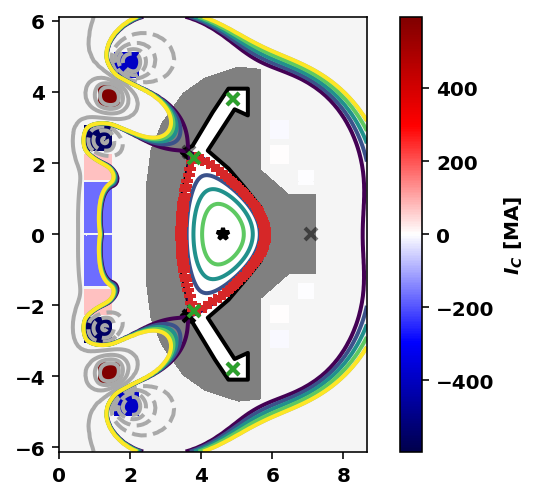

In [13]:
mygs.init_psi(4.0,0.0,0.56,1.7,0.2)
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)
# Print initial coil currents
print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key in mygs.coil_sets:
    i = mygs.coil_sets[key]['id']
    if coil_currents[key] >= 0.0:
        proximity = coil_currents[key]*100/coil_bounds[key][1]
        near_limit = coil_bounds[key][1]
    else:
        proximity = coil_currents[key]*100/coil_bounds[key][0]
        near_limit = coil_bounds[key][0]
    print('  {0:10} {1:10.2F} ({2:7.2F}) [{3:6.2F}%]'.format(key+":",coil_currents[key]/1.E3,near_limit/1.E3,proximity))

### Solve the equilibrium

`solve` is then called to compute a self-consitent Grad-Shafranov equilibrium. If the result variable (`err_flag`) is zero then the solution has converged to the desired tolerance ($10^{-6}$ by default).

In [14]:
mygs.solve()
psi0 = mygs.get_psi(normalized=False)
coil_currents, _ = mygs.get_coil_currents()

 Saddle loc_before:    3.7777550358710172       -2.2860153364068179     
 cell_active:           35
 Cell:           65
 Saddle loc:    3.6601313637708097       -2.3039233079158379     
 Saddle loc_before:    4.8881681052554189       -3.8853034625779630     
 cell_active:          495
 Cell:          108
 Saddle loc:    4.9088027677690151       -3.8056922909661672     
 Saddle loc_before:    4.8310897206813905        3.8022938569457452     
 cell_active:          214
 Cell:          392
 Saddle loc:    4.9070288444256054        3.8090652133862939     
 Saddle loc_before:    3.7968379025954366        2.2721751673288288     
 cell_active:          757
 Cell:          685
 Saddle loc:    3.6603104021116022        2.3040806171259298     
 Saddle loc_before:    4.5844952376488664       -6.0588394663542142E-002
 cell_active:         1363
 Cell:          867
 Saddle loc:    4.6093479532514765        2.5420186880683270E-004
 Saddle loc_before:    7.0809540599389731       -3.7540615210024386E-0

### Print equilibrium information and coil currents
Basic parameters can be displayed using the `print_info` method. For access to these quantities as variables instead the `get_stats` can be used.

The final coil currents can also be retrieved using the `get_coil_currents` method, which are all within the approximate coil limits imposed above.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.2000E+07
  Current Centroid [m]    =    4.610 -0.000
  Magnetic Axis [m]       =    4.695 -0.000
  Elongation              =    1.850 (U:  1.849, L:  1.852)
  Triangularity           =    0.693 (U:  0.695, L:  0.691)
  Plasma Volume [m^3]     =   191.500
  q_0, q_95               =   -0.863 -3.307
  Plasma Pressure [Pa]    =   Axis:  3.1984E+06, Peak:  3.1984E+06
  Stored Energy [J]       =    2.0590E+08
  <Beta_pol> [%]          =   90.3949
  Diamagnetic flux [Wb]   =   -2.1492E-01
  Toroidal flux [Wb]      =   -8.2591E+01
  l_i                     =    1.4066


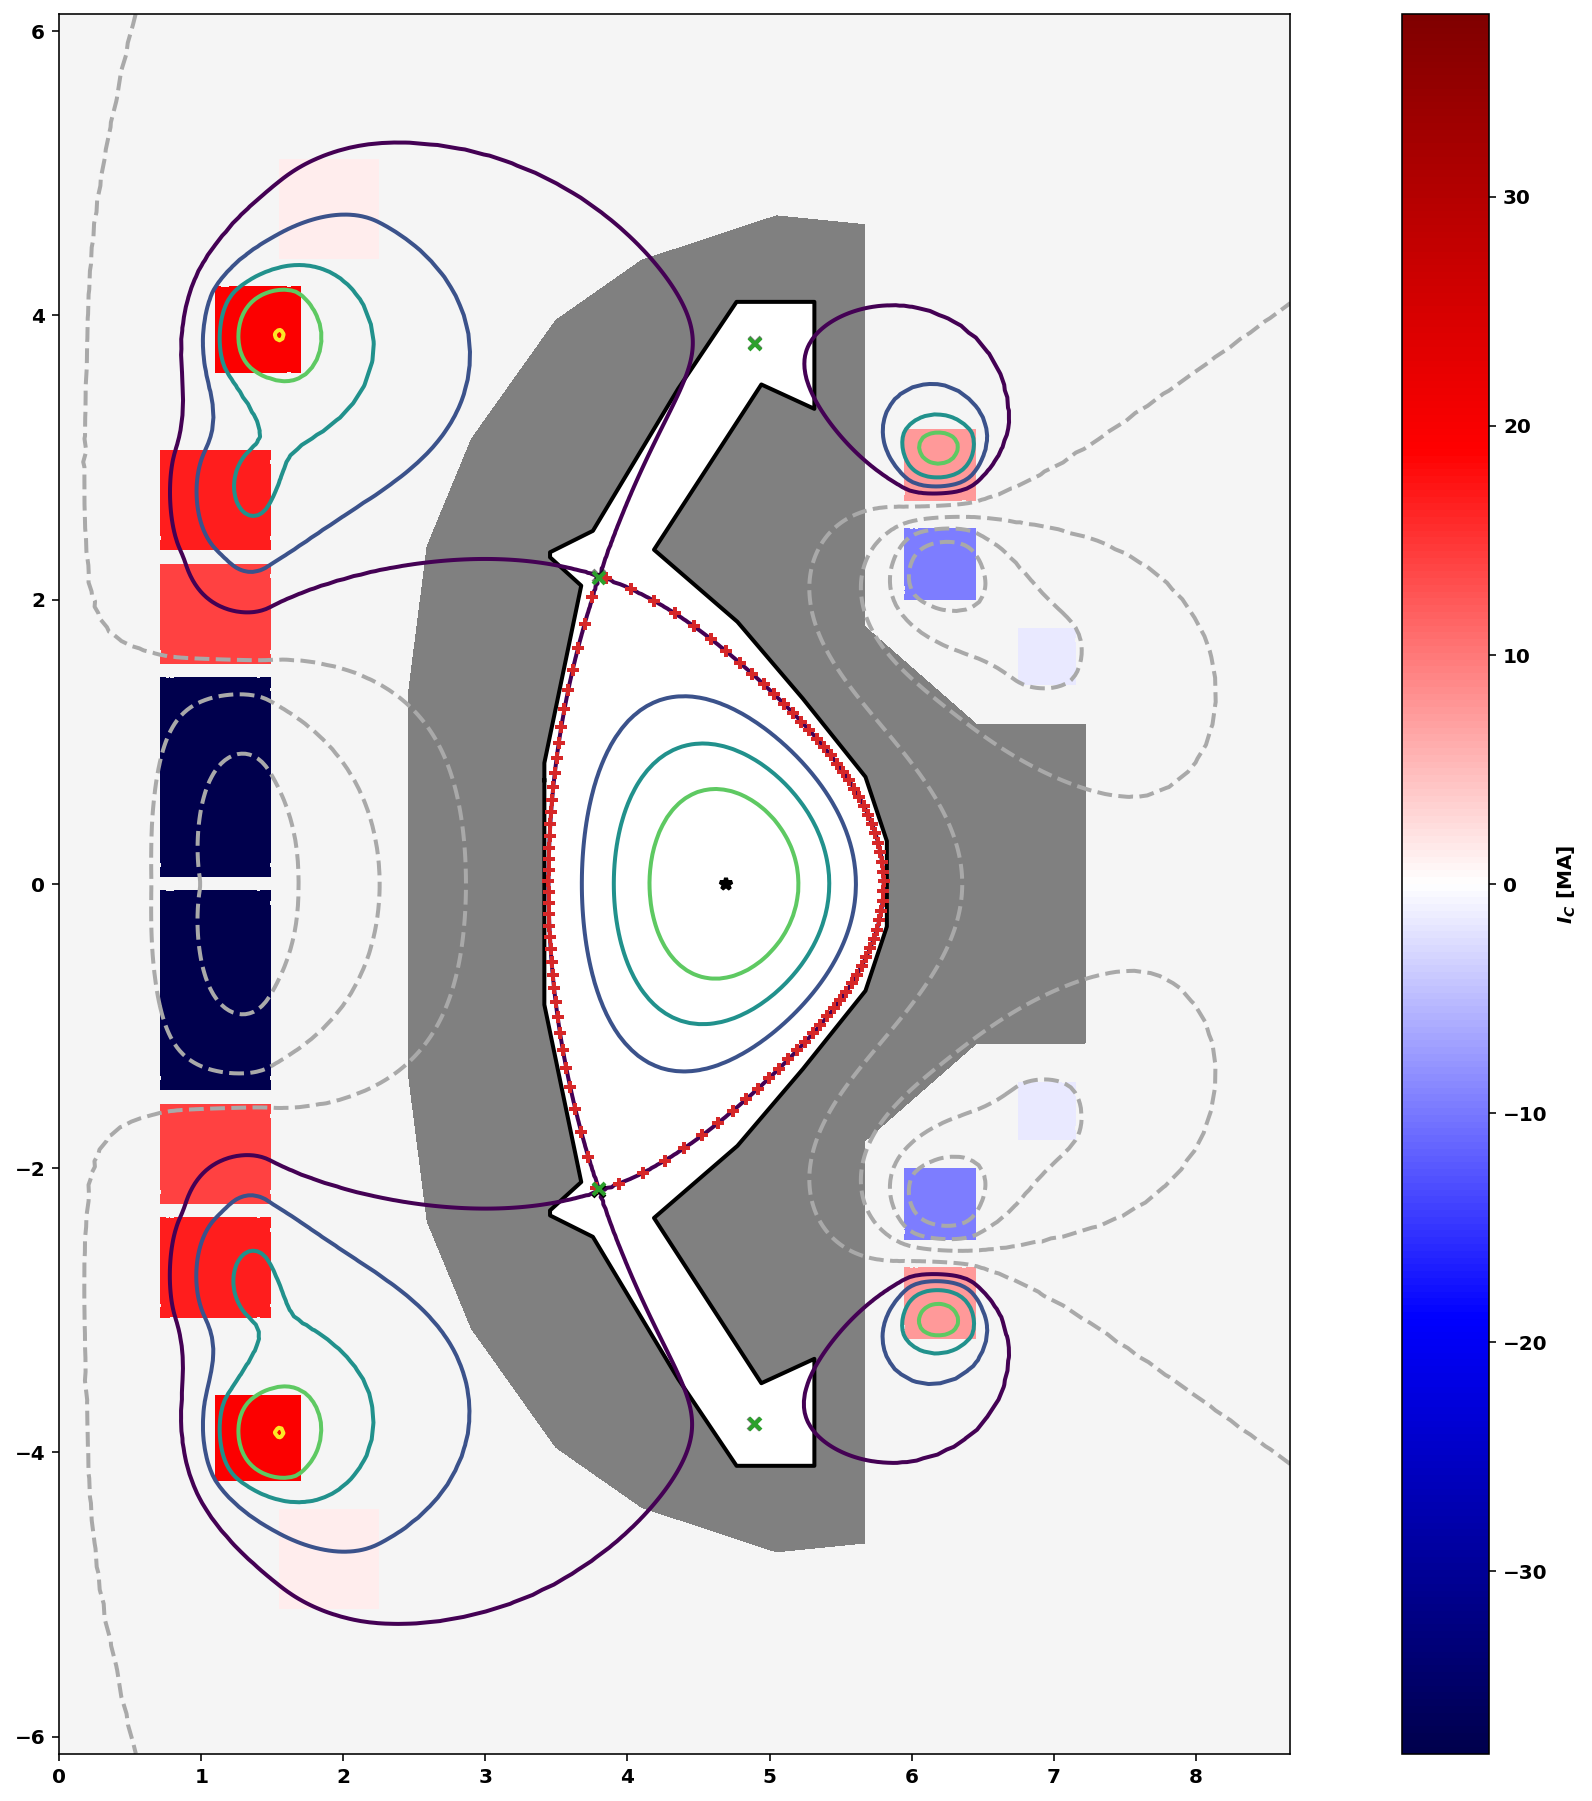


Coil Currents [kA]:
  CS1U:         -378.82 (-600000.00) [  0.06%]
  CS1L:         -379.64 (-600000.00) [  0.06%]
  CS2U:          140.74 (600000.00) [  0.02%]
  CS2L:          141.04 (600000.00) [  0.02%]
  CS3U:          167.69 (600000.00) [  0.03%]
  CS3L:          168.43 (600000.00) [  0.03%]
  PF1U:          195.46 (600000.00) [  0.03%]
  PF1L:          195.54 (600000.00) [  0.03%]
  PF2U:           13.74 (600000.00) [  0.00%]
  PF2L:           13.08 (600000.00) [  0.00%]
  PF3U:           75.18 (600000.00) [  0.01%]
  PF3L:           75.31 (600000.00) [  0.01%]
  PF4U:          -95.49 (-600000.00) [  0.02%]
  PF4L:          -95.60 (-600000.00) [  0.02%]
  PF5U:          -17.67 (-600000.00) [  0.00%]
  PF5L:          -17.64 (-600000.00) [  0.00%]


In [15]:
### Print equilibrium information and coil currents

mygs.print_info()
# Plot first case surfaces
fig, ax = plt.subplots(1,1, figsize=(20,16))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)

plt.show()
# Print final coil currents
print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key in mygs.coil_sets:
    i = mygs.coil_sets[key]['id']
    if coil_currents[key] >= 0.0:
        proximity = coil_currents[key]*100/coil_bounds[key][1]
        near_limit = coil_bounds[key][1]
    else:
        proximity = coil_currents[key]*100/coil_bounds[key][0]
        near_limit = coil_bounds[key][0]
    print('  {0:10} {1:10.2F} ({2:7.2F}) [{3:6.2F}%]'.format(key+":",coil_currents[key]/1.E3,near_limit/1.E3,proximity))

### Plot coil currents and targets

/tmp/ipykernel_2347006/3165949470.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(coil_names, rotation = 90)


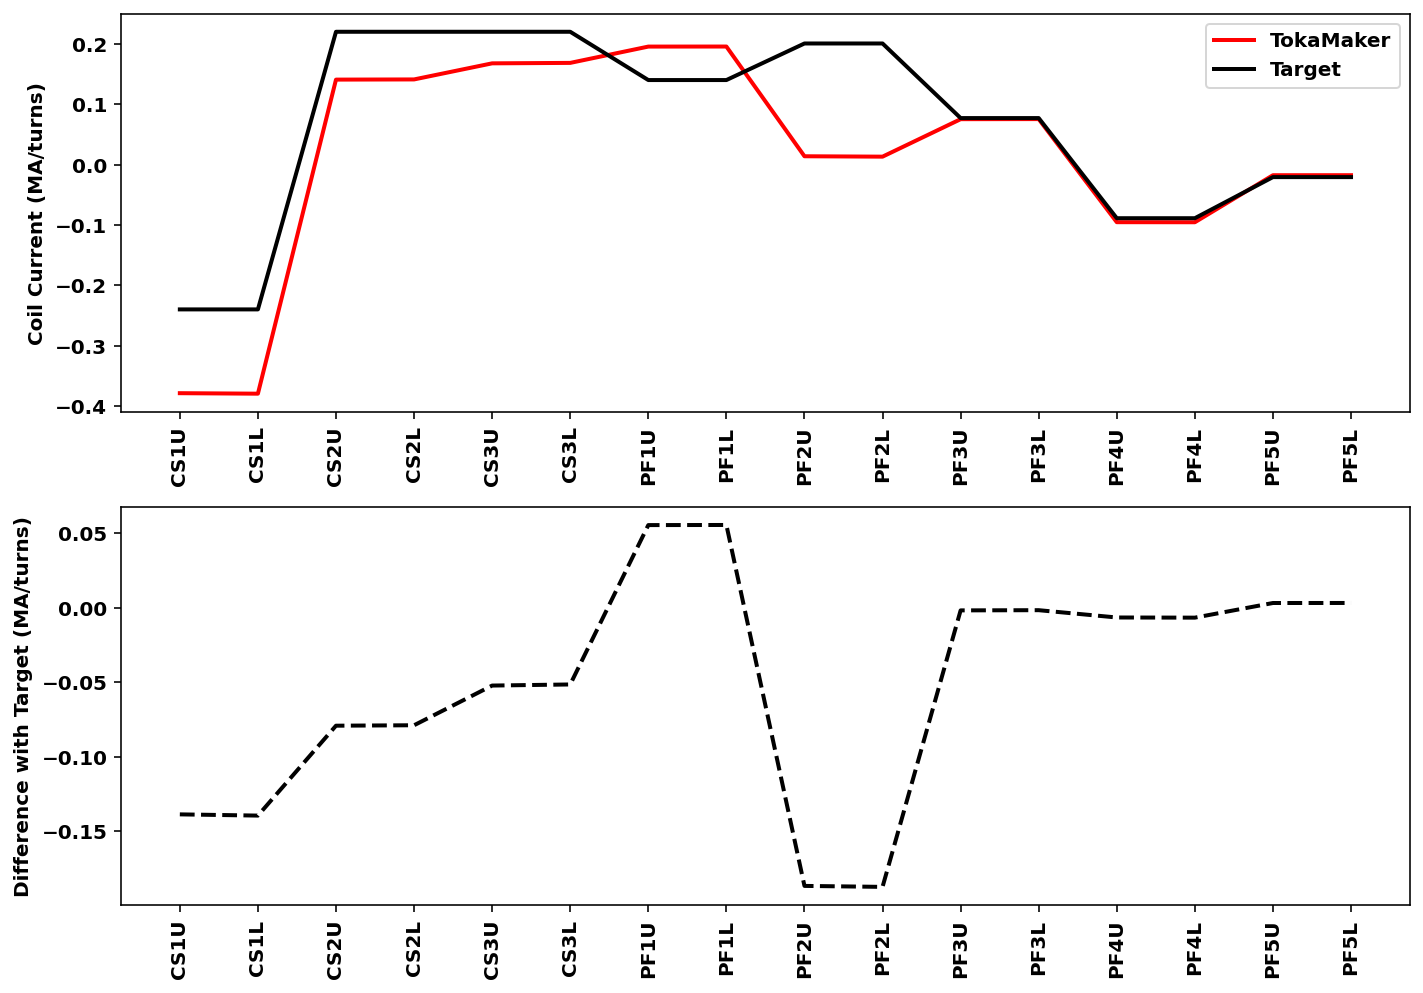

In [16]:
currents, currents_reg = mygs.get_coil_currents()
## Plot the coil currents

plt.figure

fig, axs = plt.subplots(2,1, figsize=(10,7))
curr_plot = np.array([currents[name] for name in coil_names])
target_plot = np.array([coil_targets_all[equil_init][name] for name in coil_names])
axs[0].plot(coil_names, curr_plot/1e6, c='r', label='TokaMaker')
axs[0].plot(coil_names, target_plot/1e6, c='k', label='Target')
axs[1].plot(coil_names, curr_plot/1e6-target_plot/1e6, c='k', ls='--')
    
axs[0].set_ylabel('Coil Current (MA/turns)')
axs[1].set_ylabel('Difference with Target (MA/turns)')
for ax in axs:
    ax.set_xticklabels(coil_names, rotation = 90)
plt.tight_layout()
axs[0].legend()
plt.show()

In [17]:
print(*coil_currents.values(), sep=", ")

-378817.10344971623, -379639.8747294587, 140735.51874176282, 141035.6826113424, 167689.8457029239, 168430.4797981891, 195458.1230095766, 195542.48380642282, 13738.510846783356, 13084.886872400552, 75180.55117033512, 75314.90037128382, -95492.05948311593, -95599.83947480096, -17665.142671110447, -17638.26171085818


In [24]:
coil_dict

{'CS1U': {'reg_id': 8,
  'coil_id': 0,
  'nturns': 100,
  'coil_set': 'CS1U',
  'allow_xpoints': False},
 'CS1L': {'reg_id': 9,
  'coil_id': 1,
  'nturns': 100,
  'coil_set': 'CS1L',
  'allow_xpoints': False},
 'CS2U': {'reg_id': 10,
  'coil_id': 2,
  'nturns': 100,
  'coil_set': 'CS2U',
  'allow_xpoints': False},
 'CS2L': {'reg_id': 11,
  'coil_id': 3,
  'nturns': 100,
  'coil_set': 'CS2L',
  'allow_xpoints': False},
 'CS3U': {'reg_id': 12,
  'coil_id': 4,
  'nturns': 100,
  'coil_set': 'CS3U',
  'allow_xpoints': False},
 'CS3L': {'reg_id': 13,
  'coil_id': 5,
  'nturns': 100,
  'coil_set': 'CS3L',
  'allow_xpoints': False},
 'PF1U': {'reg_id': 14,
  'coil_id': 6,
  'nturns': 100,
  'coil_set': 'PF1U',
  'allow_xpoints': False},
 'PF1L': {'reg_id': 15,
  'coil_id': 7,
  'nturns': 100,
  'coil_set': 'PF1L',
  'allow_xpoints': False},
 'PF2U': {'reg_id': 16,
  'coil_id': 8,
  'nturns': 100,
  'coil_set': 'PF2U',
  'allow_xpoints': False},
 'PF2L': {'reg_id': 17,
  'coil_id': 9,
  'nturn

In [25]:
cond_dict

{'CHANNEL': {'reg_id': 3,
  'cond_id': 0,
  'eta': 0.005,
  'noncontinuous': False,
  'allow_xpoints': True},
 'VESSEL_INNER': {'reg_id': 4,
  'cond_id': 1,
  'eta': 6e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'VESSEL_OUTER': {'reg_id': 5,
  'cond_id': 2,
  'eta': 6e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'BLANKET': {'reg_id': 6,
  'cond_id': 3,
  'eta': 7.4e-07,
  'noncontinuous': False,
  'allow_xpoints': True},
 'FLIBE': {'reg_id': 7,
  'cond_id': 4,
  'eta': 0.005,
  'noncontinuous': False,
  'allow_xpoints': True}}

In [26]:
eq['rcentr']*eq['bcentr']

-52.668

In [18]:
mygs.alam

15.0831317852506

In [19]:
mygs.pnorm

0.8570286683786386


### Save equilibrium to gEQDSK format

In [29]:
# eig_vals, eig_vecs = mygs.eig_td(-5.E3,10,False) 
# fig, ax = plt.subplots(1,1)

# neigvec = 1

# mygs.plot_machine(fig,ax,limiter_color=None)
# mygs.plot_psi(fig,ax,eig_vecs[neigvec,:],normalized=False,xpoint_color=None,opoint_color=None)
# print('Growth rate = {0:.4E} [s^-1]'.format(-eig_vals[neigvec,0]))
# print('Growth time = {0:.4E} [s]'.format(-1.0/eig_vals[neigvec,0]))
plt.show()

In [ ]:
# psi0 = np.copy(mygs.get_psi(normalized=False))
# mygs.set_psi(psi0-4.0*eig_vecs[neigvec,:])

In [11]:
# Trim 'mesh/R' in 'arc_eq.h5' to only the first two columns and rewrite as shape (np, 2)
import h5py
import numpy as np

fname = 'arc_eq.h5'
ds_path = 'mesh/R'

with h5py.File(fname, 'r+') as f:
    if ds_path not in f:
        print(f"Dataset '{ds_path}' not found in {fname}. Available keys: {list(f.keys())}")
    else:
        data = f[ds_path][:]
        if data.ndim != 2:
            raise ValueError(f"Unexpected dataset rank for {ds_path}: {data.ndim}")

        # Case: dataset stored as (dim, np) e.g. (3, np) or (2,np)
        if data.shape[0] in (2, 3) and data.shape[1] >= 2:
            new = data[:2, :].T   # -> (np,2)
        # Case: dataset stored as (np, dim)
        elif data.shape[1] in (2, 3) and data.shape[0] >= 1:
            new = data[:, :2]     # already (np,2)
        else:
            raise ValueError(f"Unrecognized mesh/R layout with shape {data.shape}")

        # Replace dataset atomically: delete and recreate
        del f[ds_path]
        f.create_dataset(ds_path, data=new)
        print(f"Rewrote '{ds_path}' in {fname} with shape {new.shape} (np,2)")

Rewrote 'mesh/R' in arc_eq.h5 with shape (18172, 2) (np,2)


In [12]:
rpts = extract_psi_from_h5('arc_eq.h5', 'mesh/R')


Success: Extracted 'mesh/R' from arc_eq.h5. Shape: (18172, 2)


In [9]:
import h5py
import numpy as np

def extract_psi_from_h5(file_path, dataset_name='tokamaker/PSI'):
    """
    Opens an HDF5 file and extracts a specific dataset as a NumPy array.
    """
    try:
        # Open the file in read-only mode ('r')
        with h5py.File(file_path, 'r') as h5_file:
            
            # Check if the field exists at the root level
            if dataset_name in h5_file:
                # The [:] syntax loads the entire dataset into memory as a NumPy array
                psi_data = h5_file[dataset_name][:]
                print(f"Success: Extracted '{dataset_name}' from {file_path}. Shape: {psi_data.shape}")
                return psi_data
            else:
                print(f"Warning: '{dataset_name}' not found at the root of {file_path}.")
                print(f"Available keys at root level: {list(h5_file.keys())}")
                return None
                
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found in the current directory.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred while reading '{file_path}': {e}")
        return None

# --- Main Execution ---

# 1. Define your file paths
eq_file = 'arc_eq.h5'
pert_file = 'arc_pert.h5'

# 2. Extract the 'psi' fields
psi_eq = extract_psi_from_h5(eq_file)
psi_pert = extract_psi_from_h5(pert_file)


# mygs.set_psi(psi_eq-4.0*psi_pert)

Success: Extracted 'tokamaker/PSI' from arc_eq.h5. Shape: (290245,)
Success: Extracted 'tokamaker/PSI' from arc_pert.h5. Shape: (290245,)


In [32]:
mygs.set_psi(psi_eq-4.0*psi_pert)

In [33]:
mygs.settings.pm=True
mygs.update_settings()
mygs.set_isoflux(None)
mygs.setup_td(1.E-3,5.E-9,1.E-8)

In [34]:
import time
sim_time = 0.0
dt = 5.E-3
nplot = 1
nstatus = 1
results = [mygs.get_psi()]
results_raw = [mygs.get_psi(False)]
t00 = time.perf_counter()
for i in range(1):
    t0 = time.perf_counter()
    sim_time, _, nl_its, lin_its, nretry = mygs.step_td(sim_time,dt)
    t1 = time.perf_counter()
    if i % nstatus == 0:
        print('{0:.5E} {1:.5E} {2:4d} {3:4d} {5:8.3f} {4:4d}'.format(sim_time,dt,nl_its,lin_its,nretry,t1-t0))
        print(mygs.alam)
    if i % nplot == 0:
        results.append(mygs.get_psi())
        results_raw.append(mygs.get_psi(False))
    print(mygs.psi_bounds)
t1 = time.perf_counter()
print('Total time = {0:8.3f}'.format(t1-t00))

Starting Newton solver
 Saddle loc_before:    3.7340360531718044       -2.1562614050584985     
 cell_active:           32
 Cell:           63
 Saddle loc:    3.8001743379185724       -2.1670449813460491     
 Saddle loc_before:    4.9648406183589291       -3.7078694763780113     
 cell_active:          959
 Cell:          172
 Saddle loc:    4.8916550139676414       -3.8018257030287939     
 Saddle loc_before:    4.8310897206813905        3.8022938569457452     
 cell_active:          214
 Cell:          392
 Saddle loc:    4.8969272357706846        3.8054221966169082     
 Saddle loc_before:    3.8908085857817021        2.1201842777214477     
 cell_active:          759
 Cell:          686
 Saddle loc:    3.8027952019676210        2.1583246420517943     
 Saddle loc_before:    4.6953320129020257       -4.5947762081021112E-006
 cell_active:         1366
 Cell:          865
 Saddle loc:    4.6953285602822135       -4.5242746368208148E-003
 Updated plasma bounds:   4.9996186862065892   

 Saddle loc_before:    3.7340360531718044       -2.1562614050584985     
 cell_active:           32
 Cell:           63
 Saddle loc:    3.8012844184237968       -2.1627316398738352     
 Saddle loc_before:    4.9648406183589291       -3.7078694763780113     
 cell_active:          959
 Cell:          172
 Saddle loc:    4.8921744322886953       -3.8027673723396656     
 Saddle loc_before:    4.8310897206813905        3.8022938569457452     
 cell_active:          214
 Cell:          392
 Saddle loc:    4.8968460943168308        3.8042651992141701     
 Saddle loc_before:    3.8908085857817021        2.1201842777214477     
 cell_active:          759
 Cell:          686
 Saddle loc:    3.8017197271891536        2.1626594871410227     
 Saddle loc_before:    4.6953378028152324       -3.9799678263079837E-006
 cell_active:         1366
 Cell:          865
 Saddle loc:    4.6953378023968799       -3.9799695729509658E-006
 Updated plasma bounds:   4.9948008093986545        13.736275318929417

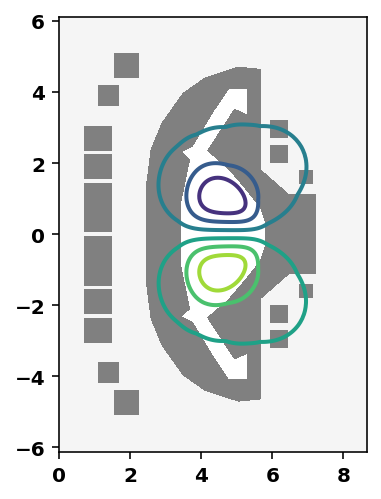

In [20]:
eig_vals, eig_vecs = mygs.eig_td(-5.E3,10,False) 
fig, ax = plt.subplots(1,1)

neigvec = 1

mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,eig_vecs[neigvec,:],normalized=False,xpoint_color=None,opoint_color=None)
print('Growth rate = {0:.4E} [s^-1]'.format(-eig_vals[neigvec,0]))
print('Growth time = {0:.4E} [s]'.format(-1.0/eig_vals[neigvec,0]))
plt.show()